# MySNCF Experience — Récap de l'exploration

Version courte de l'analyse exploratoire, tournée vers le produit : un **« Google Maps du train »**
(trains qui se déplacent sur la carte, trajet jusqu'au lieu, dernier kilomètre ; prix et alertes via l'API SNCF, plus tard).

Le détail complet (et les expériences) reste dans `eda_exploratoire.ipynb`. Ici : ce qu'on a, ce qui manque, ce qui est faisable.

| # | Question |
|---|---|
| 1 | Quelles données a-t-on, et que valent-elles (valeurs manquantes) ? |
| 2 | Que couvre-t-on du produit, et que manque-t-il ? |
| 3 | Peut-on faire circuler des trains sur une carte à partir des horaires ? |
| 4 | Le dernier kilomètre est-il un vrai sujet ? |
| 5 | Décisions pour la suite |

In [1]:
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve()
while not (ROOT / "lib").is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError("Racine du projet introuvable (dossier lib/ absent)")
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.set_option("display.max_columns", 40, "display.max_colwidth", 80, "display.width", 200)

# ── Configuration ──────────────────────────────────────────────────────────
SOURCES = [
    "gares_voyageurs", "horaires_gares", "horaires_sncf_gtfs", "lignes_par_region",
    "basilic", "datatourisme_place", "datatourisme_fma", "qualite_tourisme", "epv", "festivals",
    "vls_paris_velib", "velo_stationnement_gares_centre_val_de_loire",
]
REF_DATE = pd.Timestamp("2026-10-06")        # date de l'instantané des données
HORIZON_FIN = pd.Timestamp("2026-12-31")     # rien après fin 2026 (récurrences dépliées jusqu'en 2100 = artefact)
JOUR = pd.Timestamp("2026-10-07")            # jour simulé sur la carte des trains (doit être couvert par le GTFS)

In [ ]:
# Fonctions de l'exploration (lecture, géographie, simulation des trains depuis le GTFS)
import json
import re


from lib.downloader import download

DATA_DIR = ROOT / os.environ.get("DATA_DIR", "data")
SEED = 42
R_TERRE_KM = 6371.0

TABULAR = {".csv", ".txt", ".tsv", ".parquet"}
POIDS_TRANCHES = {"≤ 1 km": 1.0, "1-5 km": 0.5, "5-25 km": 0.1, "> 25 km": 0.0}   # hypothèse de travail
TRANCHES_BINS = [-np.inf, 1, 5, 25, np.inf]


# ── Téléchargement et lecture ───────────────────────────────────────────────────
def has_data(source):
    d = DATA_DIR / source
    return d.is_dir() and any(p.is_file() and p.name != ".gitkeep" for p in d.rglob("*"))


def ensure_sources(sources, force=False):
    """Télécharge les sources absentes du disque. Retourne {source: erreur} pour celles qui échouent."""
    echecs = {}
    for s in sources:
        if force or not has_data(s):
            try:
                download([s])
            except Exception as e:
                echecs[s] = f"{type(e).__name__}: {str(e)[:120]}"
    return echecs


def _clean_cols(df):
    df.columns = [str(c).replace("﻿", "").strip() for c in df.columns]
    return df


def read_table(path, max_rows=500_000):
    """Lit un CSV/TXT/Parquet de façon tolérante. Retourne (df, nb_lignes_approx, echantillonne)."""
    rng = np.random.default_rng(SEED)
    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
        total = len(df)
        return _clean_cols(df.sample(max_rows, random_state=SEED) if total > max_rows else df), total, total > max_rows

    with open(path, "rb") as f:
        head = f.read(65536).decode("utf-8-sig", errors="replace").replace("﻿", "")
    first = head.splitlines()[0] if head else ""
    sep = max(",;\t|", key=first.count)
    with open(path, "rb") as f:
        total = sum(1 for _ in f) - 1

    sampled = total > 1.5 * max_rows
    frac = max_rows / total if sampled else 1.0
    skip = (lambda i: i > 0 and rng.random() > frac) if sampled else None
    for enc in ("utf-8-sig", "latin-1"):
        for kw in ({"low_memory": False}, {"engine": "python", "on_bad_lines": "skip"}):
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc, skiprows=skip, nrows=None if sampled else max_rows, **kw)
                return _clean_cols(df), total, sampled or total > max_rows
            except UnicodeDecodeError:
                break
            except Exception:
                continue
    raise ValueError(f"illisible : {path.name}")


def load_tables(sources, max_rows=500_000):
    """Charge toutes les tables des sources. Retourne (dict nom→DataFrame, catalogue, illisibles)."""
    tables, rows, bad = {}, [], {}
    for s in sources:
        d = DATA_DIR / s
        for p in sorted(d.rglob("*")) if d.is_dir() else []:
            if p.suffix.lower() not in TABULAR or not p.is_file():
                continue
            key = f"{s}/{p.stem}"
            try:
                df, total, sampled = read_table(p, max_rows)
            except Exception as e:
                bad[key] = str(e)[:100]
                continue
            if df.shape[0] == 0 or df.shape[1] < 2:
                bad[key] = f"vide ou non tabulaire {df.shape}"
                continue
            tables[key] = df
            rows.append(dict(table=key, source=s, lignes=len(df), lignes_fichier=total, echantillon=sampled,
                             colonnes=df.shape[1], taille_Mo=round(p.stat().st_size / 1e6, 1)))
    return tables, pd.DataFrame(rows).set_index("table"), bad


def find(tables, fragment):
    """Première table dont le nom contient `fragment` (None si absente)."""
    return next((df for k, df in tables.items() if fragment in k), None)


def missing_report(tables):
    """Une ligne par colonne : table, colonne, % de valeurs manquantes, nombre de valeurs distinctes."""
    rows = []
    for k, df in tables.items():
        for c in df.columns:
            s = df[c]
            try:
                nu = int(s.nunique(dropna=True))
            except TypeError:
                nu = -1
            rows.append(dict(table=k, colonne=c, manquants_pct=round(100 * s.isna().mean(), 1), uniques=nu))
    return pd.DataFrame(rows)


# ── Temps ──────────────────────────────────────────────────────────────────────
def explode_periods(df, col="Periodes_regroupees"):
    """Périodes d'événements « AAAA-MM-JJ<->AAAA-MM-JJ » (plusieurs par événement) → une ligne par période."""
    pairs = df[col].dropna().str.findall(r"(\d{4}-\d{2}-\d{2})<->(\d{4}-\d{2}-\d{2})").explode().dropna()
    out = pd.DataFrame(pairs.tolist(), index=pairs.index, columns=["deb", "fin"])
    return out.apply(pd.to_datetime, errors="coerce").dropna()


def active_events(df, ref_date, horizon):
    """Événements en cours ou à venir avant l'horizon (les périodes au-delà, souvent des récurrences dépliées, sont coupées)."""
    per = explode_periods(df)
    per = per[(per.deb <= horizon) & (per.fin >= per.deb)].assign(fin=lambda d: d.fin.clip(upper=horizon))
    ev = per.groupby(level=0).agg(deb=("deb", "min"), fin=("fin", "max"))
    return ev[ev.fin >= ref_date]


# ── Géographie ──────────────────────────────────────────────────────────────────
def pair_from_strings(s, order="latlon"):
    """Extrait deux nombres d'une chaîne ('48.8, 2.3' ou '[2.3,48.8]'). order='lonlat' pour les JSON GeoJSON."""
    e = s.astype(str).str.extract(r"(-?\d+(?:\.\d+)?)\s*,\s*(-?\d+(?:\.\d+)?)").astype(float)
    return (e[0], e[1]) if order == "latlon" else (e[1], e[0])


def in_metro(g, corse=False):
    """Points en France métropolitaine (Corse exclue par défaut : pas de gares dans gares_voyageurs)."""
    ok = g.lat.between(41, 51.5) & g.lon.between(-5.5, 10)
    if not corse:
        ok &= ~((g.lat < 43.1) & (g.lon > 8.4))
    return g[ok]


GEO_SPEC = [   # (calque, fragment de table, colonne(s), mode)
    ("gares", "gares_voyageurs", "Position géographique", "pair_latlon"),
    ("basilic", "basilic", ("Latitude", "Longitude"), "cols"),
    ("datatourisme", "datatourisme_place", ("Latitude", "Longitude"), "cols"),
    ("événements", "datatourisme_fma", ("Latitude", "Longitude"), "cols"),
    ("vélo_gares_cvl", "velo_stationnement", "coordonneesxy", "pair_lonlat"),
    ("velib", "vls_paris_velib", "Coordonnées géographiques", "pair_latlon"),
]


def build_geo(tables, spec=GEO_SPEC):
    """Calques {nom: DataFrame(lat, lon)} alignés sur l'index de leur table, quel que soit le format source."""
    geo = {}
    for name, frag, col, mode in spec:
        df = find(tables, frag)
        if df is None:
            continue
        if mode == "cols":
            if not set(col) <= set(df.columns):
                continue
            lat, lon = pd.to_numeric(df[col[0]], errors="coerce"), pd.to_numeric(df[col[1]], errors="coerce")
        else:
            if col not in df:
                continue
            lat, lon = pair_from_strings(df[col], "latlon" if mode == "pair_latlon" else "lonlat")
        geo[name] = pd.DataFrame({"lat": lat, "lon": lon}, index=df.index)
    return geo


def nearest_km(points, stations):
    """Distance (km, à vol d'oiseau) de chaque point à la gare la plus proche."""
    from sklearn.neighbors import BallTree
    tree = BallTree(np.radians(stations[["lat", "lon"]].values), metric="haversine")
    d, _ = tree.query(np.radians(points[["lat", "lon"]].values), k=1)
    return d[:, 0] * R_TERRE_KM


def _dep_from_postal(s):
    return s.astype(str).str.extract(r"(\d{5})")[0].str[:2]


def build_sites(tables, ref_date, horizon):
    """Tableau unique des sites (culture, tourisme, événements à venir) avec distance à la gare, tranche, poids et département.

    Retourne (POIS, noms_departements). POIS est vide si les sources nécessaires manquent.
    """
    geo = build_geo(tables)
    if "gares" not in geo:
        return pd.DataFrame(), {}
    stations = in_metro(geo["gares"]).dropna()

    parts, noms = [], {}
    def add(label, layer, dep, keep=None):
        if layer not in geo:
            return
        p = in_metro(geo[layer]).dropna()
        if keep is not None:
            p = p.loc[p.index.intersection(keep)]
        p = p.assign(km=nearest_km(p, stations), source=label, dep=dep.reindex(p.index))
        parts.append(p)

    b = find(tables, "basilic")
    if b is not None and "N_Département" in b:
        dep_b = b["N_Département"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(2)
        add("Culture (Basilic)", "basilic", dep_b)
        if "Département" in b:
            tmp = pd.DataFrame({"c": dep_b, "n": b["Département"]}).dropna().drop_duplicates("c")
            noms = tmp.set_index("c").n.to_dict()
    dtm = find(tables, "datatourisme_place")
    if dtm is not None:
        add("Tourisme (DATATourisme)", "datatourisme", _dep_from_postal(dtm.Code_postal_et_commune))
    fma = find(tables, "datatourisme_fma")
    if fma is not None and "Periodes_regroupees" in fma:
        actifs = active_events(fma, ref_date, horizon)
        add("Événements à venir (fin 2026)", "événements", _dep_from_postal(fma.Code_postal_et_commune), keep=actifs.index)

    if not parts:
        return pd.DataFrame(), noms
    pois = pd.concat(parts, ignore_index=True)
    pois["tranche"] = pd.cut(pois.km, TRANCHES_BINS, labels=list(POIDS_TRANCHES))
    pois["w"] = pois.tranche.map(POIDS_TRANCHES).astype(float)
    return pois, noms


# ── Trains en mouvement (GTFS) ──────────────────────────────────────────────────
def _secs(s):
    """'HH:MM:SS' → secondes ; HH peut dépasser 24 (service de nuit rattaché au jour précédent)."""
    p = s.astype("string").str.split(":", expand=True).astype(float)
    return p[0] * 3600 + p[1] * 60 + p[2]


def load_gtfs(folder):
    """Charge les tables GTFS utiles à la simulation depuis un dossier de data/."""
    d = DATA_DIR / folder
    g = {n: pd.read_csv(d / f"{n}.txt", low_memory=False) for n in ["stops", "trips", "routes", "calendar_dates"]}
    g["stop_times"] = pd.read_csv(d / "stop_times.txt", usecols=["trip_id", "arrival_time", "departure_time", "stop_id", "stop_sequence"])
    return g


def build_schedule(gtfs):
    """Une ligne par tronçon (arrêt → arrêt suivant) avec heures en secondes et coordonnées des deux extrémités."""
    st = gtfs["stop_times"].sort_values(["trip_id", "stop_sequence"]).copy()
    st["arr"], st["dep"] = _secs(st.arrival_time), _secs(st.departure_time)
    st["arr"], st["dep"] = st.arr.fillna(st.dep), st.dep.fillna(st.arr)
    sp = gtfs["stops"].set_index("stop_id")
    st["lat"], st["lon"] = st.stop_id.map(sp.stop_lat), st.stop_id.map(sp.stop_lon)
    g = st.groupby("trip_id")
    st["next_arr"], st["next_lat"], st["next_lon"] = g.arr.shift(-1), g.lat.shift(-1), g.lon.shift(-1)
    st["service"] = st.stop_id.str.extract(r"StopPoint:OCE(.+?)-\d")[0].fillna("Autre")
    return st.drop(columns=["arrival_time", "departure_time"])


def active_trips(gtfs, when):
    """Voyages circulant à l'instant `when` d'après le calendrier (calendar_dates, exception_type=1)."""
    cd, trips = gtfs["calendar_dates"], gtfs["trips"]
    t = when.hour * 3600 + when.minute * 60 + when.second
    ids = []
    for back_days, tt in ((0, t), (1, t + 86400)):                    # services du jour, et ceux de la veille après minuit
        day = int((when.normalize() - pd.Timedelta(days=back_days)).strftime("%Y%m%d"))
        sv = cd.loc[(cd.date == day) & (cd.exception_type == 1), "service_id"]
        ids.append((set(trips.loc[trips.service_id.isin(sv), "trip_id"]), tt))
    return ids


def train_positions(gtfs, sched, when):
    """Position interpolée (ligne droite entre deux arrêts) de chaque train en circulation à `when`."""
    out = []
    for trip_ids, tt in active_trips(gtfs, when):
        s = sched[sched.trip_id.isin(trip_ids)]
        mv = s[(s.dep <= tt) & (s.next_arr > tt)].copy()
        f = (tt - mv.dep) / (mv.next_arr - mv.dep)
        mv["lat"], mv["lon"] = mv.lat + f * (mv.next_lat - mv.lat), mv.lon + f * (mv.next_lon - mv.lon)
        mv["etat"] = "en marche"
        dw = s[(s.arr <= tt) & (s.dep > tt)].copy()
        dw["etat"] = "à quai"
        out += [mv, dw]
    pos = pd.concat(out, ignore_index=True).dropna(subset=["lat", "lon"])
    tr = gtfs["trips"].set_index("trip_id")
    pos["route_id"] = pos.trip_id.map(tr.route_id)
    pos["numero"] = pos.trip_id.map(tr.trip_headsign)               # trip_headsign contient le numéro de train
    rt = gtfs["routes"].set_index("route_id")
    pos["ligne"] = pos.route_id.map(rt.route_long_name)
    pos["type"] = pos.route_id.map(rt.route_type)
    return pos[["trip_id", "numero", "lat", "lon", "etat", "service", "ligne", "type"]]


def haversine_km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * R_TERRE_KM * np.arcsin(np.sqrt(a))


def rail_network(tables):
    """Tronçons de voies ferrées (GeoJSON de lignes_par_region) → liste de tableaux [[lon, lat], ...]."""
    df = find(tables, "lignes_par_region")
    if df is None or "Geo Shape" not in df:
        return []
    lines = []
    for raw in df["Geo Shape"].dropna():
        try:
            geom = json.loads(raw)
        except (TypeError, ValueError):
            continue
        coords = geom.get("coordinates", [])
        if geom.get("type") == "MultiLineString":
            lines += [np.array(c) for c in coords]
        elif coords:
            lines.append(np.array(coords))
    return lines

In [2]:
echecs = ensure_sources(SOURCES)                       # télécharge seulement ce qui manque sur le disque
DF, CAT, ILLISIBLES = load_tables(SOURCES)
print(f"{len(DF)} tables chargées depuis {len(SOURCES)} sources", "| échecs :" if echecs else "", echecs or "")

18 tables chargées depuis 12 sources  


## 1. Les données : ce qu'on a et ce qu'elles valent

Une source n'est utilisable que si ses colonnes sont remplies. On mesure donc la part de valeurs manquantes
et on repère les colonnes à écarter (≥ 80 % vides) ou sans information (une seule valeur).

In [3]:
MISS = missing_report(DF)
par_table = MISS.groupby("table").agg(colonnes=("colonne", "size"), manquants_moyen_pct=("manquants_pct", "mean"),
                                      vides_80pct=("manquants_pct", lambda s: int((s >= 80).sum())),
                                      constantes=("uniques", lambda s: int((s <= 1).sum())))
INV = CAT[["lignes", "taille_Mo", "echantillon"]].join(par_table).sort_values("manquants_moyen_pct", ascending=False)
display(INV.style.format({"manquants_moyen_pct": "{:.1f}", "taille_Mo": "{:.1f}"})
        .background_gradient(subset=["manquants_moyen_pct"], cmap="Reds", vmin=0, vmax=50))

,lignes,taille_Mo,echantillon,colonnes,manquants_moyen_pct,vides_80pct,constantes
table,,,,,,,
basilic/base-des-lieux-et-des-equipements-culturels,86366,49.0,False,54,42.8,20,8
horaires_sncf_gtfs/stops,8829,0.7,False,9,37.7,3,3
festivals/festivals-global-festivals-pl,7283,2.6,False,30,37.6,7,0
horaires_sncf_gtfs/routes,744,0.1,False,9,28.5,2,3
velo_stationnement_gares_centre_val_de_loire/data,167,0.0,False,21,25.3,5,3
horaires_sncf_gtfs/stop_times,500000,85.0,True,9,22.2,2,2
epv/entreprises-du-patrimoine-vivant-epv,1267,0.8,False,22,17.2,0,0
datatourisme_fma/datatourisme-fma,77164,58.6,False,15,16.8,2,1
datatourisme_place/datatourisme-place,354912,272.7,False,14,15.9,1,0


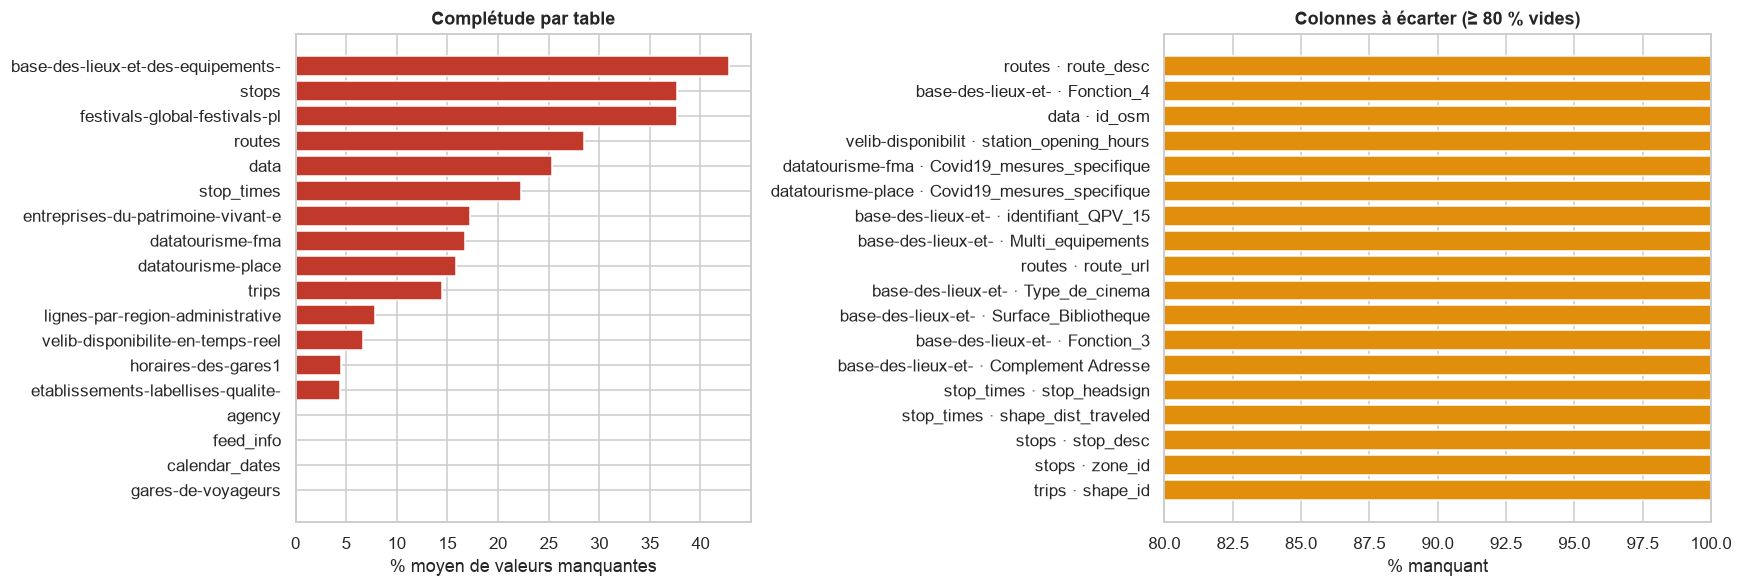

267 colonnes au total : 44 sont vides à 80 % ou plus, 19 n'ont qu'une seule valeur → à ne pas charger dans le produit.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 1.2]})
t = INV.manquants_moyen_pct.sort_values()
axes[0].barh([k.split("/")[-1][:34] for k in t.index], t.values, color="#c0392b")
axes[0].set_xlabel("% moyen de valeurs manquantes"); axes[0].set_title("Complétude par table")

vides = MISS[MISS.manquants_pct >= 80].sort_values("manquants_pct", ascending=False).head(18)
labels = [f"{r.table.split('/')[-1][:18]} · {r.colonne[:26]}" for r in vides.itertuples()]
axes[1].barh(labels[::-1], vides.manquants_pct.values[::-1], color="#e08e0b")
axes[1].set_xlim(80, 100); axes[1].set_xlabel("% manquant"); axes[1].set_title("Colonnes à écarter (≥ 80 % vides)")
plt.tight_layout(); plt.show()

n80, n1 = int((MISS.manquants_pct >= 80).sum()), int((MISS.uniques == 1).sum())
print(f"{len(MISS)} colonnes au total : {n80} sont vides à 80 % ou plus, {n1} n'ont qu'une seule valeur → à ne pas charger dans le produit.")

## 2. Que couvre-t-on du produit ?

Constat issu de l'exploration (pas un calcul) : pour chaque fonction du « Google Maps du train », la donnée disponible et ce qui manque.

In [5]:
COUV = pd.DataFrame([
    ("Horaires des trains (TGV, TER, Intercités…)", "GTFS SNCF", "Disponible", "Tous les voyages ont leurs horaires et les arrêts leurs coordonnées ; planning publié jusqu'en mars 2027"),
    ("Trains qui se déplacent sur la carte", "GTFS SNCF (simulation)", "Disponible", "Positions calculées d'après les horaires théoriques, pas les positions réelles"),
    ("Tracé réel des voies", "lignes_par_region", "Partiel", "Le GTFS n'a aucun tracé (shape_id vide) ; les tronçons de voie sont dans lignes_par_region, à relier aux trains"),
    ("Retards et temps réel", "API SNCF", "Manquant", "Hors des fichiers ouverts : à intégrer via l'API"),
    ("Prix des billets", "API (en cours de configuration)", "Manquant", "Aucune source ouverte trouvée"),
    ("Alertes sur les lignes", "API SNCF", "Manquant", "À intégrer via l'API"),
    ("Gares : horaires d'ouverture, accessibilité", "gares_voyageurs, horaires_gares, accessibilité (XML)", "Disponible", "Couvre ~2 800 gares ; la Corse n'est pas dans gares_voyageurs"),
    ("Lieux culturels et touristiques", "Basilic, DATATourisme", "Disponible", "Pas d'horaires d'ouverture ni de prix ; doublons possibles entre sources"),
    ("Événements", "DATATourisme (manifestations)", "Disponible", "Périodes à nettoyer : récurrences dépliées jusqu'en 2100, coupées à fin 2026"),
    ("Dernier km : vélos", "Vélib' Paris, stationnement vélo CVL", "Partiel", "Peu de villes ; Vélov, flux GBFS et aménagements cyclables à ajouter"),
    ("Dernier km : bus, tram", "GTFS urbains (dans le .env)", "Partiel", "21 réseaux déclarés, non chargés ; agrégats régionaux à explorer"),
    ("Places TGVmax", "tgvmax", "Disponible", "Instantané sur ~30 jours, utile comme indice de disponibilité"),
], columns=["Besoin", "Données", "Statut", "Détail"])

couleurs = {"Disponible": "#cfe8d5", "Partiel": "#fbe3b5", "Manquant": "#f4c7c3"}
display(COUV.style.hide(axis="index").map(lambda v: f"background-color: {couleurs.get(v, '')}", subset=["Statut"])
        .set_properties(subset=["Détail"], **{"white-space": "normal"}))
print(COUV.Statut.value_counts().to_dict())

Besoin,Données,Statut,Détail
"Horaires des trains (TGV, TER, Intercités…)",GTFS SNCF,Disponible,Tous les voyages ont leurs horaires et les arrêts leurs coordonnées ; planning publié jusqu'en mars 2027
Trains qui se déplacent sur la carte,GTFS SNCF (simulation),Disponible,"Positions calculées d'après les horaires théoriques, pas les positions réelles"
Tracé réel des voies,lignes_par_region,Partiel,"Le GTFS n'a aucun tracé (shape_id vide) ; les tronçons de voie sont dans lignes_par_region, à relier aux trains"
Retards et temps réel,API SNCF,Manquant,Hors des fichiers ouverts : à intégrer via l'API
Prix des billets,API (en cours de configuration),Manquant,Aucune source ouverte trouvée
Alertes sur les lignes,API SNCF,Manquant,À intégrer via l'API
"Gares : horaires d'ouverture, accessibilité","gares_voyageurs, horaires_gares, accessibilité (XML)",Disponible,Couvre ~2 800 gares ; la Corse n'est pas dans gares_voyageurs
Lieux culturels et touristiques,"Basilic, DATATourisme",Disponible,Pas d'horaires d'ouverture ni de prix ; doublons possibles entre sources
Événements,DATATourisme (manifestations),Disponible,"Périodes à nettoyer : récurrences dépliées jusqu'en 2100, coupées à fin 2026"
Dernier km : vélos,"Vélib' Paris, stationnement vélo CVL",Partiel,"Peu de villes ; Vélov, flux GBFS et aménagements cyclables à ajouter"


{'Disponible': 6, 'Partiel': 3, 'Manquant': 3}


## 3. Peut-on faire circuler des trains sur une carte ?

Principe : pour un instant donné, on retient les voyages actifs ce jour-là (calendrier GTFS), on trouve pour chacun le tronçon
entre deux arrêts où il se trouve, et on **interpole sa position** entre les deux gares selon l'heure. À quai si l'heure est entre son arrivée et son départ.

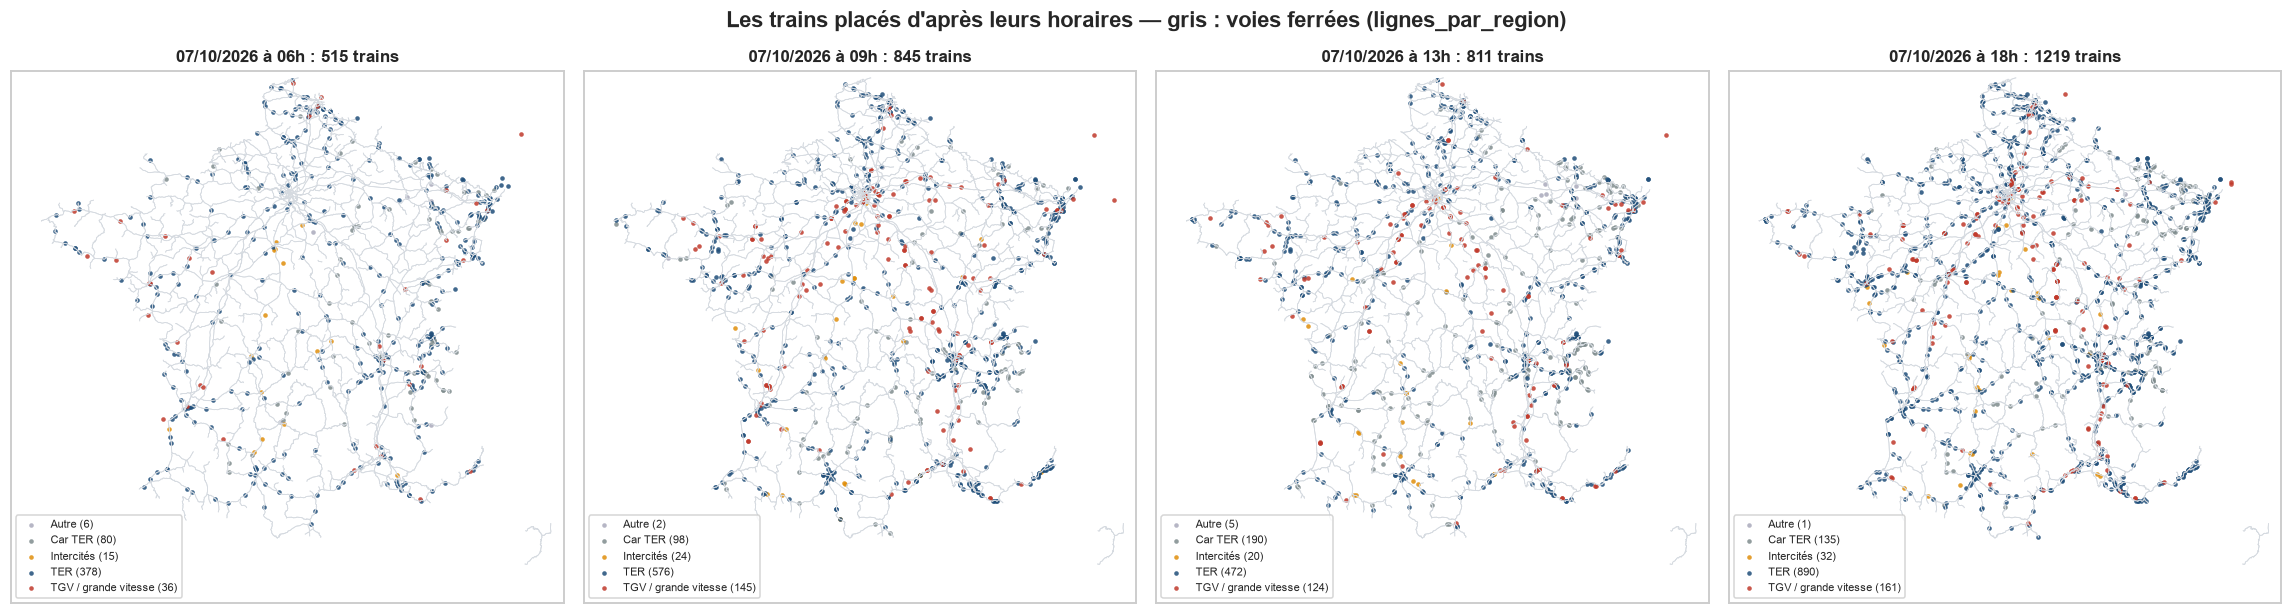

In [6]:
GT = load_gtfs("horaires_sncf_gtfs")
SCHED = build_schedule(GT)
RAIL = rail_network(DF)

GROUPES = {"TGV INOUI": "TGV / grande vitesse", "OUIGO": "TGV / grande vitesse", "Lyria": "TGV / grande vitesse", "ICE": "TGV / grande vitesse",
           "Train TER": "TER", "TramTrain": "TER", "INTERCITES": "Intercités", "INTERCITES de nuit": "Intercités", "Car TER": "Car TER"}
COULEURS_G = {"TGV / grande vitesse": "#c0392b", "TER": "#1f4e79", "Intercités": "#e08e0b", "Car TER": "#7f8c8d", "Autre": "#aab"}

def snapshot(h):
    p = train_positions(GT, SCHED, JOUR + pd.Timedelta(hours=h))
    p["groupe"] = p.service.map(GROUPES).fillna("Autre")
    return p[p.lat.between(41, 51.5) & p.lon.between(-5.5, 10)]               # France métropolitaine (Corse comprise)

HEURES = [6, 9, 13, 18]
fig, axes = plt.subplots(1, 4, figsize=(21, 5.8))
for ax, h in zip(axes, HEURES):
    ax.add_collection(LineCollection(RAIL, colors="#d5dae0", linewidths=.5))
    p = snapshot(h)
    for g, d in p.groupby("groupe"):
        ax.scatter(d.lon, d.lat, s=9, color=COULEURS_G[g], label=f"{g} ({len(d)})", alpha=.85, linewidths=0)
    ax.set_xlim(-5.3, 9.8); ax.set_ylim(41.2, 51.2); ax.set_aspect(1 / np.cos(np.radians(46.5)))
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"{JOUR:%d/%m/%Y} à {h:02d}h : {len(p)} trains", fontsize=11)
    ax.legend(loc="lower left", fontsize=7, frameon=True)
fig.suptitle("Les trains placés d'après leurs horaires — gris : voies ferrées (lignes_par_region)", fontweight="bold")
plt.tight_layout(); plt.show()

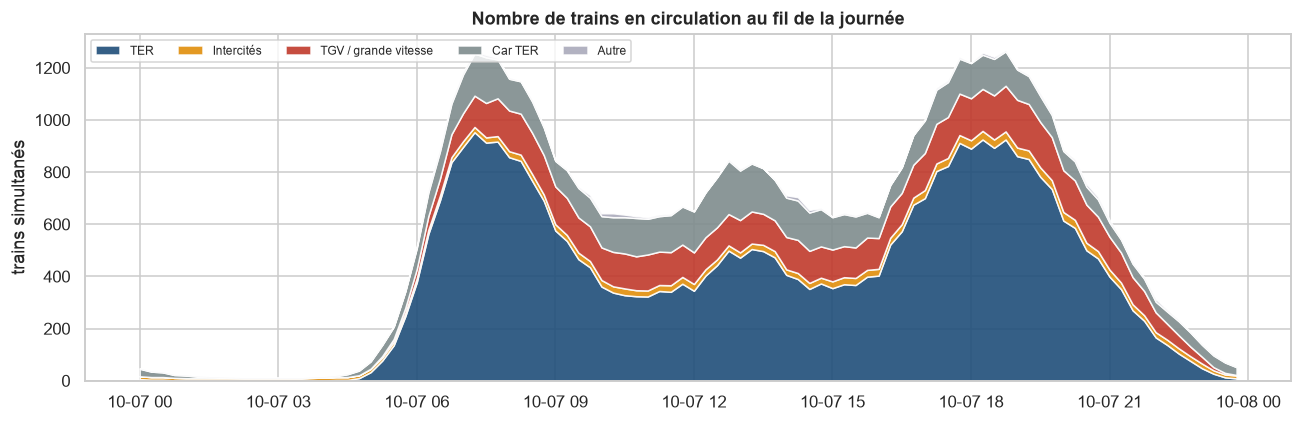

Pointe : 1267 trains simultanés à 18:45 ; creux de nuit : 12.


In [7]:
# Le pouls du réseau sur 24 h (toutes les 15 minutes)
serie = []
for m in range(0, 24 * 60, 15):
    p = train_positions(GT, SCHED, JOUR + pd.Timedelta(minutes=m))
    g = p.service.map(GROUPES).fillna("Autre").value_counts()
    serie.append(pd.Series(g, name=JOUR + pd.Timedelta(minutes=m)))
PULSE = pd.DataFrame(serie).fillna(0)
ordre = [c for c in ["TER", "Intercités", "TGV / grande vitesse", "Car TER", "Autre"] if c in PULSE]
fig, ax = plt.subplots(figsize=(12, 4))
ax.stackplot(PULSE.index, [PULSE[c] for c in ordre], labels=ordre, colors=[COULEURS_G[c] for c in ordre], alpha=.9)
ax.set_title("Nombre de trains en circulation au fil de la journée"); ax.set_ylabel("trains simultanés")
ax.legend(loc="upper left", ncol=len(ordre), fontsize=8); plt.tight_layout(); plt.show()
PIC = PULSE.sum(axis=1)
print(f"Pointe : {int(PIC.max())} trains simultanés à {PIC.idxmax():%H:%M} ; creux de nuit : {int(PIC.min())}.")

### Les trains suivent-ils les voies ?
Le GTFS ne donne pas le tracé : entre deux gares, la position est calculée **en ligne droite**. On mesure si c'est acceptable en comparant
chaque position simulée aux voies de `lignes_par_region`. Si l'écart est faible, une carte « ligne droite » suffit pour les TER ;
sinon il faut caler les trains sur le réseau de voies.

,trains,ecart_median_km,à_moins_de_1km_pct
groupe,,,
Autre,2.0,1.8,50.0
Car TER,98.0,0.6,68.4
Intercités,24.0,1.3,41.7
TER,499.0,0.4,74.5
TGV / grande vitesse,136.0,2.9,27.9
Tous,759.0,0.6,64.3


Lecture : la ligne droite colle aux voies pour les TER (75% à moins de 1 km) mais pas pour les TGV (28%), dont les arrêts sont très espacés → pour ces trains, caler la position sur le réseau de voies est nécessaire.


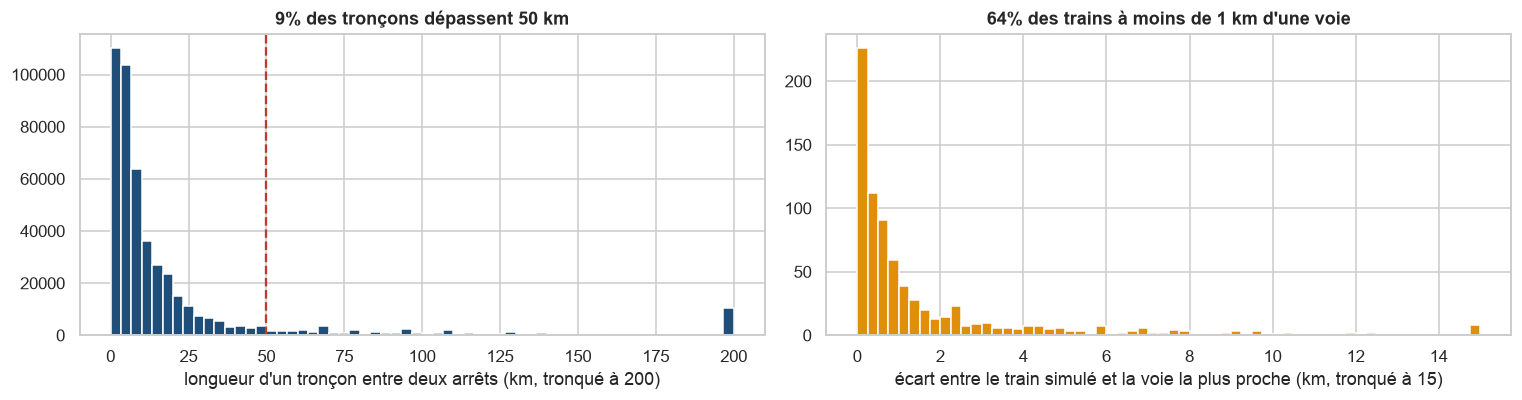

In [8]:
from sklearn.neighbors import BallTree

seg = SCHED.dropna(subset=["next_arr", "next_lat"])
seg_km = haversine_km(seg.lat, seg.lon, seg.next_lat, seg.next_lon)

verts = np.vstack(RAIL)[:, ::-1]                              # [lon, lat] → [lat, lon]
tree = BallTree(np.radians(verts), metric="haversine")
p = snapshot(9)
p = p[p.etat == "en marche"].copy()
p["ecart_km"] = tree.query(np.radians(p[["lat", "lon"]].values), k=1)[0][:, 0] * R_TERRE_KM

res = p.groupby("groupe").agg(trains=("ecart_km", "size"), ecart_median_km=("ecart_km", "median"),
                              à_moins_de_1km_pct=("ecart_km", lambda s: 100 * (s <= 1).mean()))
res.loc["Tous"] = [len(p), p.ecart_km.median(), 100 * (p.ecart_km <= 1).mean()]
display(res.round(1))
ter, tgv = res.loc["TER", "à_moins_de_1km_pct"], res.loc["TGV / grande vitesse", "à_moins_de_1km_pct"]
print(f"Lecture : la ligne droite colle aux voies pour les TER ({ter:.0f}% à moins de 1 km) mais pas pour les TGV ({tgv:.0f}%), "
      "dont les arrêts sont très espacés → pour ces trains, caler la position sur le réseau de voies est nécessaire.")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
axes[0].hist(seg_km.clip(upper=200), bins=60, color="#1f4e79"); axes[0].axvline(50, color="#c0392b", ls="--")
axes[0].set_xlabel("longueur d'un tronçon entre deux arrêts (km, tronqué à 200)")
axes[0].set_title(f"{100 * (seg_km > 50).mean():.0f}% des tronçons dépassent 50 km")
axes[1].hist(p.ecart_km.clip(upper=15), bins=60, color="#e08e0b")
axes[1].set_xlabel("écart entre le train simulé et la voie la plus proche (km, tronqué à 15)")
axes[1].set_title(f"{100 * (p.ecart_km <= 1).mean():.0f}% des trains à moins de 1 km d'une voie")
plt.tight_layout(); plt.show()

## 4. Le dernier kilomètre est-il un vrai sujet ?

Pour chaque site (culture, tourisme, événements à venir avant fin 2026), distance à vol d'oiseau à la gare voyageurs la plus proche.
**Indice d'Accessibilité Ferroviaire (IAF, 0-100)** : moyenne pondérée selon la distance (≤ 1 km = 1, 1-5 km = 0,5, 5-25 km = 0,1, au-delà = 0).
Les poids sont une hypothèse de travail (`POIDS_TRANCHES`).

489 630 sites analysés (Corse et outre-mer exclus).


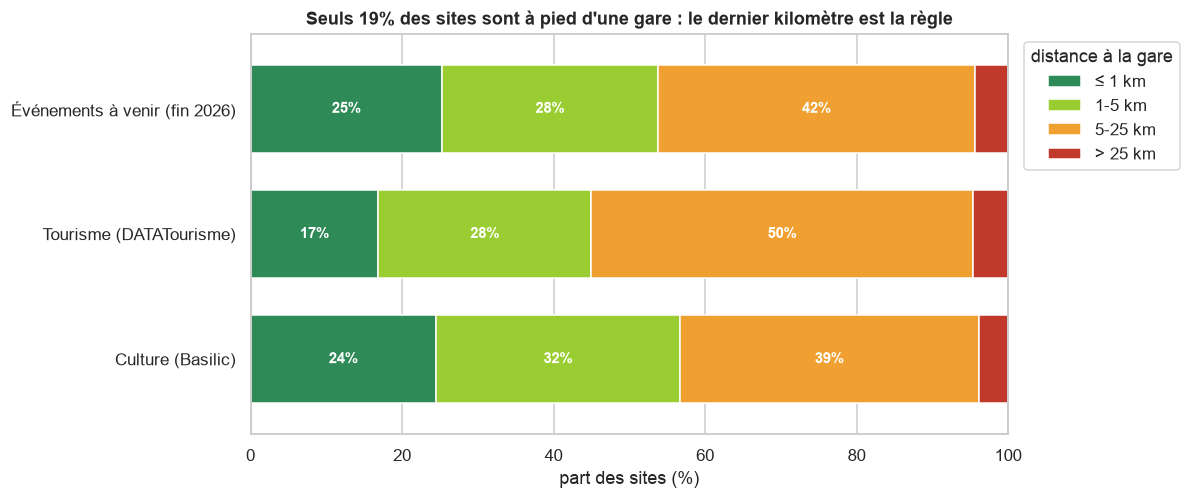

In [9]:
POIS, NOMS = build_sites(DF, REF_DATE, HORIZON_FIN)
LABELS = list(POIDS_TRANCHES)
COUL = ["#2e8b57", "#9acd32", "#f0a030", "#c0392b"]
print(f"{len(POIS):,} sites analysés (Corse et outre-mer exclus).".replace(",", " "))

share = POIS.groupby("source").tranche.value_counts(normalize=True).unstack().reindex(columns=LABELS) * 100
fig, ax = plt.subplots(figsize=(11, 3.2 + 0.5 * len(share)))
share.plot.barh(stacked=True, ax=ax, color=COUL, width=.7)
for i, (_, row) in enumerate(share.iterrows()):
    x = 0
    for lab in LABELS:
        if row[lab] >= 6:
            ax.text(x + row[lab] / 2, i, f"{row[lab]:.0f}%", ha="center", va="center", color="white", fontsize=10, fontweight="bold")
        x += row[lab]
ax.set_xlim(0, 100); ax.set_xlabel("part des sites (%)"); ax.set_ylabel("")
ax.legend(title="distance à la gare", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title(f"Seuls {100 * POIS.km.le(1).mean():.0f}% des sites sont à pied d'une gare : le dernier kilomètre est la règle")
plt.tight_layout(); plt.show()

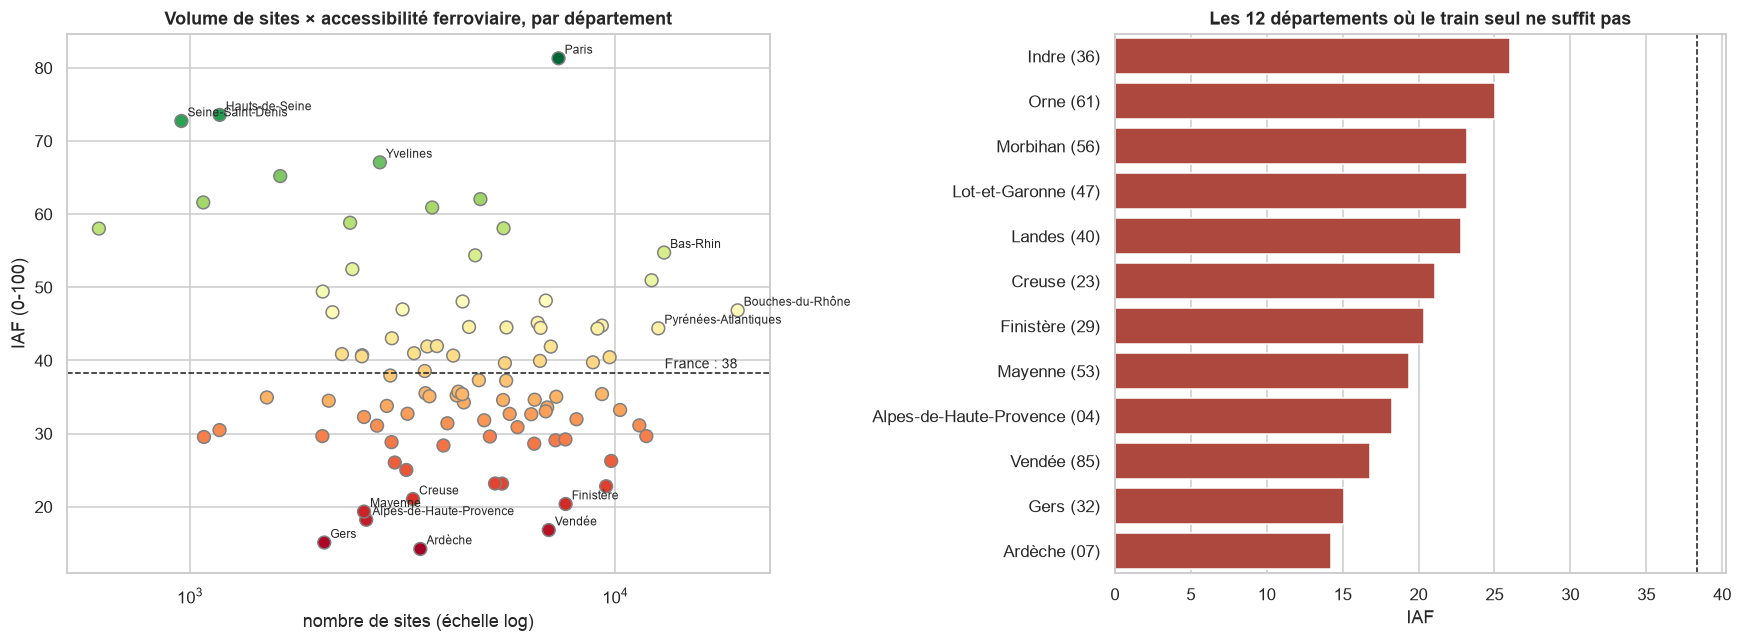

In [10]:
DEPS = (POIS.dropna(subset=["dep"]).groupby("dep")
        .agg(sites=("km", "size"), IAF=("w", lambda w: 100 * w.mean())).query("sites >= 300"))
DEPS["nom"] = [f"{NOMS.get(d, d)} ({d})" for d in DEPS.index]
iaf_nat = 100 * POIS.w.mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
ax.scatter(DEPS.sites, DEPS.IAF, c=DEPS.IAF, cmap="RdYlGn", s=70, edgecolor="grey")
ax.set_xscale("log"); ax.axhline(iaf_nat, color="k", ls="--", lw=1); ax.text(DEPS.sites.max(), iaf_nat + .6, f"France : {iaf_nat:.0f}", ha="right", fontsize=9)
for d, r in pd.concat([DEPS.nsmallest(7, "IAF"), DEPS.nlargest(4, "IAF"), DEPS.nlargest(3, "sites")]).drop_duplicates().iterrows():
    ax.annotate(r.nom.split(" (")[0], (r.sites, r.IAF), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("nombre de sites (échelle log)"); ax.set_ylabel("IAF (0-100)"); ax.set_title("Volume de sites × accessibilité ferroviaire, par département")
worst = DEPS.nsmallest(12, "IAF").sort_values("IAF", ascending=False)
sns.barplot(x=worst.IAF, y=worst.nom, ax=axes[1], color="#c0392b"); axes[1].axvline(iaf_nat, color="k", ls="--", lw=1)
axes[1].set_xlabel("IAF"); axes[1].set_ylabel(""); axes[1].set_title("Les 12 départements où le train seul ne suffit pas")
plt.tight_layout(); plt.show()

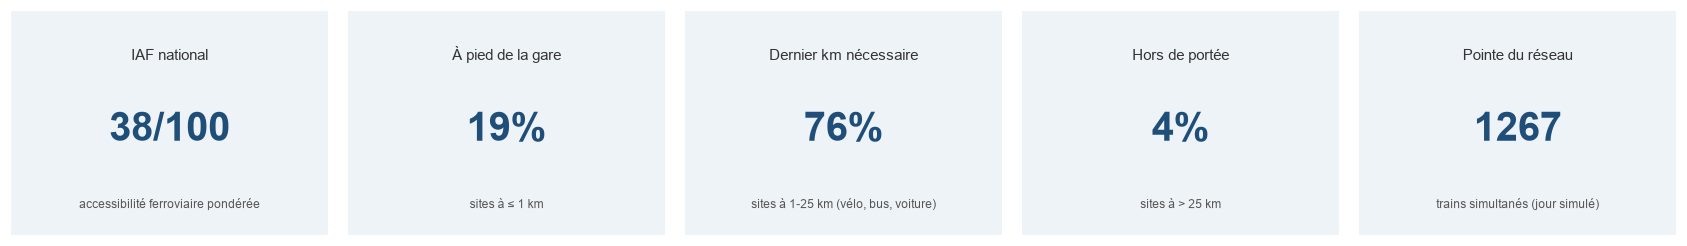

Départements les moins bien servis (≥ 300 sites) : Ardèche (07), Gers (32), Vendée (85).


In [11]:
p1, p_dernier, p_loin = 100 * POIS.km.le(1).mean(), 100 * POIS.km.between(1, 25, inclusive="right").mean(), 100 * POIS.km.gt(25).mean()
tuiles = [("IAF national", f"{iaf_nat:.0f}/100", "accessibilité ferroviaire pondérée"),
          ("À pied de la gare", f"{p1:.0f}%", "sites à ≤ 1 km"),
          ("Dernier km nécessaire", f"{p_dernier:.0f}%", "sites à 1-25 km (vélo, bus, voiture)"),
          ("Hors de portée", f"{p_loin:.0f}%", "sites à > 25 km"),
          ("Pointe du réseau", f"{int(PIC.max())}", "trains simultanés (jour simulé)")]
fig, axes = plt.subplots(1, len(tuiles), figsize=(3.1 * len(tuiles), 2.4))
for ax, (titre, val, sous) in zip(axes, tuiles):
    ax.axis("off"); ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, color="#eef3f8", zorder=0))
    ax.text(.5, .78, titre, ha="center", fontsize=10, color="#333", transform=ax.transAxes)
    ax.text(.5, .42, val, ha="center", fontsize=26, fontweight="bold", color="#1f4e79", transform=ax.transAxes)
    ax.text(.5, .12, sous, ha="center", fontsize=8, color="#555", transform=ax.transAxes)
plt.tight_layout(); plt.show()
pire = ", ".join(DEPS.nsmallest(3, "IAF").nom)
print(f"Départements les moins bien servis (≥ 300 sites) : {pire}.")

## 5. Décisions pour la suite

**Faisable tout de suite**
- La **carte des trains en mouvement** : les horaires GTFS suffisent à placer chaque train à chaque instant.
  Entre deux gares la position est en ligne droite ; pour suivre les voies, relier les tronçons de `lignes_par_region` en un graphe et y caler les trains.

**À brancher (API SNCF, côté équipe)**
- Retards et temps réel, **alertes sur les lignes** (à afficher sur le tracé), **prix** et calcul d'itinéraire.

**À ajouter côté données**
- **Dernier kilomètre** : GTFS urbains (déjà dans le `.env`), flux GBFS de vélos et trottinettes, aménagements cyclables.
- **Table de correspondance des gares** (gares voyageurs ↔ arrêts GTFS ↔ TGVmax) : indispensable avant d'afficher un trajet.
- **Doublons entre Basilic et DATATourisme** : à mesurer avant de compter des lieux.

**Écarté pour l'instant**
- Toute **prédiction de remplissage** : aucune source ouverte ne donne la fréquentation réelle des trains.
- Les analyses du laboratoire (Benford, Zipf, noms de gares…) restent dans `eda_exploratoire.ipynb`, sans suite produit.